# 02 — Lateral Movement Investigation

**Goal:** pull east-west SMB/RDP/SSH flows from Gigamon, build a NetworkX directed graph of host-to-host talkers, and visualize.

Gigamon sees this *before* the EDR does, because it lives on the wire.

## Setup

Authenticate with Azure CLI (`az login`) and load workspace coordinates from `.env`.

In [1]:
import os, datetime as dt
import pandas as pd
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.monitor.query import LogsQueryClient, LogsQueryStatus

load_dotenv()
WORKSPACE_ID = os.environ['WORKSPACE_ID']
HOURS = int(os.environ.get('TIMERANGE_HOURS', '24'))
client = LogsQueryClient(DefaultAzureCredential())
TIMESPAN = dt.timedelta(hours=HOURS)

def kql(q: str) -> pd.DataFrame:
    """Run a KQL query and return the first table as a DataFrame."""
    r = client.query_workspace(WORKSPACE_ID, q, timespan=TIMESPAN)
    if r.status != LogsQueryStatus.SUCCESS:
        raise RuntimeError(r.partial_error)
    t = r.tables[0]
    return pd.DataFrame(t.rows, columns=[c for c in t.columns])

/Users/mitchellgulledge/gigamon-sentinel-notebooks/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Pull east-west flows

In [2]:
flows = kql('''
GigamonCcfMcpDemo_CL
| where dst_port in ('22','445','3389','135','5985','5986')
| where src_ip startswith '10.' or src_ip startswith '172.16.' or src_ip startswith '192.168.'
| where dst_ip startswith '10.' or dst_ip startswith '172.16.' or dst_ip startswith '192.168.'
| summarize Flows=count(), Bytes=sum(tolong(total_bytes)) by src_ip, dst_ip, dst_port
| order by Flows desc
| take 200
''')
flows.head()

,src_ip,dst_ip,dst_port,Flows,Bytes
0,172.16.5.11,10.42.20.50,22,14,56124570
1,10.42.10.23,10.42.20.50,445,13,12174348
2,10.42.20.50,10.42.20.50,22,11,11139012
3,10.42.10.23,10.42.30.21,22,11,38162592
4,172.16.5.11,10.42.40.8,22,11,3039075


## Build the directed graph

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for _, r in flows.iterrows():
    G.add_edge(r['src_ip'], r['dst_ip'], port=r['dst_port'], weight=int(r['Flows']))
print(f'nodes={G.number_of_nodes()}, edges={G.number_of_edges()}')

nodes=6, edges=12


## Plot the lateral-movement topology

Hot edges = high flow count. Nodes with many out-edges = likely jump hosts.

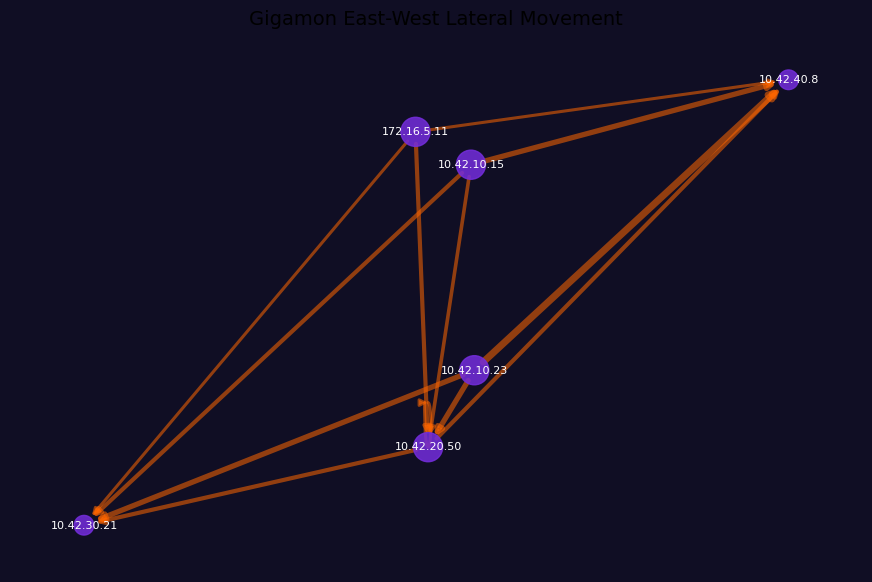

In [4]:
plt.figure(figsize=(11, 7))
pos = nx.spring_layout(G, k=0.9, seed=42)
degrees = dict(G.out_degree())
node_sizes = [200 + 80 * degrees.get(n, 0) for n in G.nodes]
weights = [G[u][v]['weight'] for u, v in G.edges]
wmax = max(weights) if weights else 1
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#742DDC', alpha=0.85)
nx.draw_networkx_edges(G, pos, width=[1 + 4*(w/wmax) for w in weights], alpha=0.55, edge_color='#FF6600', arrows=True)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.title('Gigamon East-West Lateral Movement', fontsize=14)
plt.gca().set_facecolor('#100E24'); plt.gcf().set_facecolor('#100E24')
plt.axis('off'); plt.show()

## Top jump-host candidates

In [5]:
import pandas as pd
deg = pd.DataFrame([(n, G.out_degree(n), G.in_degree(n)) for n in G.nodes],
                   columns=['ip','out_degree','in_degree'])
deg.sort_values('out_degree', ascending=False).head(10)

,ip,out_degree,in_degree
0,172.16.5.11,3,0
1,10.42.20.50,3,4
2,10.42.10.23,3,0
5,10.42.10.15,3,0
3,10.42.30.21,0,4
4,10.42.40.8,0,4
